<a href="https://colab.research.google.com/github/Umer-Ashfaq/AI-600/blob/main/24280004_PA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**AI600 – Deep Learning (Assignment 3)**

`Name:` Umer Ashfaq

`Roll Number:` 24280004

**Task 1 (Custom CNNs in Pytorch:) - Part A (Standard MNIST)**

In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split, DataLoader

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Load MNIST Dataset
transform = transforms.ToTensor()

full_train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Split original training set into train + validation
train_size = 55000
val_size = 5000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 519kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.87MB/s]

Train size: 55000
Val size: 5000
Test size: 10000


In [ ]:
# Define Custom CNN
class CustomMNISTCNN(nn.Module):
    def __init__(self):
        super(CustomMNISTCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 28x28 -> 14x14

            nn.Conv2d(8, 16, kernel_size=3, padding=1), # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 14x14 -> 7x7

            nn.Conv2d(16, 24, kernel_size=3, padding=1),# 7x7 -> 7x7
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CustomMNISTCNN().to(device)
print(model)

CustomMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1176, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [ ]:
# Define Custom CNN
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print("Total trainable parameters:", total_params)

Total trainable parameters: 42722


In [ ]:
# Optional detailed calculation
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

features.0.weight 72
features.0.bias 8
features.3.weight 1152
features.3.bias 16
features.6.weight 3456
features.6.bias 24
classifier.1.weight 37632
classifier.1.bias 32
classifier.3.weight 320
classifier.3.bias 10


In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training and Evaluation Functions
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
# Train the Model
epochs = 10

train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=epochs
)

Epoch [1/10] | Train Loss: 0.5464, Train Acc: 82.78% | Val Loss: 0.2075, Val Acc: 93.66%
Epoch [2/10] | Train Loss: 0.1400, Train Acc: 95.72% | Val Loss: 0.1125, Val Acc: 96.26%
Epoch [3/10] | Train Loss: 0.0900, Train Acc: 97.20% | Val Loss: 0.0965, Val Acc: 97.10%
Epoch [4/10] | Train Loss: 0.0704, Train Acc: 97.88% | Val Loss: 0.0715, Val Acc: 97.88%
Epoch [5/10] | Train Loss: 0.0592, Train Acc: 98.16% | Val Loss: 0.0715, Val Acc: 97.70%
Epoch [6/10] | Train Loss: 0.0524, Train Acc: 98.32% | Val Loss: 0.0599, Val Acc: 98.20%
Epoch [7/10] | Train Loss: 0.0452, Train Acc: 98.54% | Val Loss: 0.0570, Val Acc: 98.22%
Epoch [8/10] | Train Loss: 0.0409, Train Acc: 98.66% | Val Loss: 0.0464, Val Acc: 98.60%
Epoch [9/10] | Train Loss: 0.0363, Train Acc: 98.88% | Val Loss: 0.0529, Val Acc: 98.48%
Epoch [10/10] | Train Loss: 0.0329, Train Acc: 98.94% | Val Loss: 0.0512, Val Acc: 98.34%


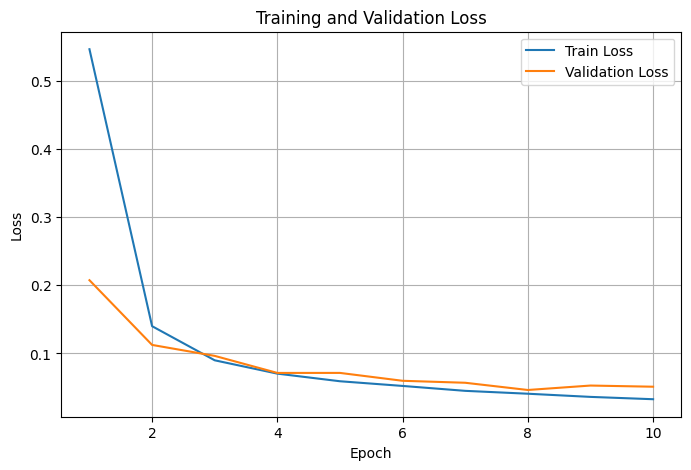

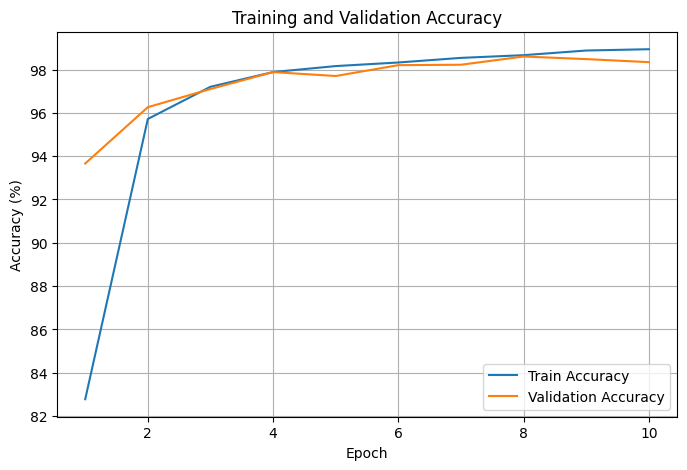

In [ ]:
# Plot Training and Validation Curves
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, epochs+1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Final Evaluation on Standard MNIST Test Set
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.0441
Test Accuracy: 98.50%


Shape of first conv weights: (8, 1, 3, 3)


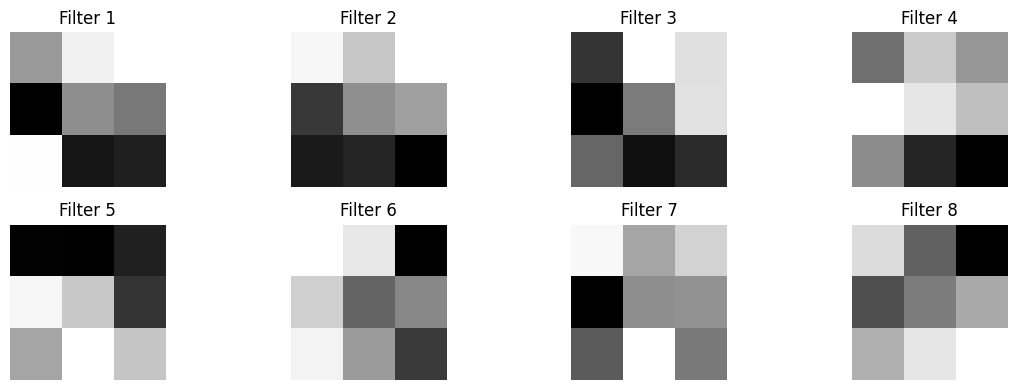

In [ ]:
# Extract and plot first-layer filters
first_conv_weights = model.features[0].weight.data.cpu().numpy()
print("Shape of first conv weights:", first_conv_weights.shape)  # [out_channels, in_channels, kH, kW]

num_filters = first_conv_weights.shape[0]

plt.figure(figsize=(12, 4))
for i in range(num_filters):
    plt.subplot(2, 4, i+1)
    plt.imshow(first_conv_weights[i, 0], cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Save Model
torch.save(model.state_dict(), "mnist_custom_cnn_partA.pth")
print("Model saved successfully.")

Model saved successfully.


**Task 1 (Custom CNNs and Shortcut Learning:) - Part B (Colored-MNIST (C-MNIST))**

In [ ]:
# Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# File Paths
train_path = "cmnist/train_biased.pt"
test_biased_path = "cmnist/test_biased.pt"
test_unbiased_path = "cmnist/test_unbiased.pt"

In [ ]:
# Robust Dataset Loader
class PTDatasetWrapper(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]

        # convert to float tensor
        if not torch.is_tensor(x):
            x = torch.tensor(x)
        x = x.float()

        if not torch.is_tensor(y):
            y = torch.tensor(y)
        y = y.long()

        # handle image shape
        # possible shapes: [H,W,3], [3,H,W], [H,W]
        if x.ndim == 2:
            x = x.unsqueeze(0).repeat(3, 1, 1)   # grayscale -> fake RGB
        elif x.ndim == 3:
            # if channel last, convert to channel first
            if x.shape[-1] == 3 and x.shape[0] != 3:
                x = x.permute(2, 0, 1)

        # normalize if values look like 0-255
        if x.max() > 1.0:
            x = x / 255.0

        return x, y


def inspect_pt_object(obj, name="dataset"):
    print(f"\n--- Inspecting {name} ---")
    print("Type:", type(obj))

    if isinstance(obj, dict):
        print("Keys:", list(obj.keys()))
        for k, v in obj.items():
            if torch.is_tensor(v):
                print(f"{k}: shape={tuple(v.shape)}, dtype={v.dtype}")
            else:
                print(f"{k}: type={type(v)}")

    elif isinstance(obj, (list, tuple)):
        print("Length:", len(obj))
        for i, item in enumerate(obj[:5]):
            if torch.is_tensor(item):
                print(f"Item {i}: tensor shape={tuple(item.shape)}, dtype={item.dtype}")
            else:
                print(f"Item {i}: type={type(item)}")

    elif torch.is_tensor(obj):
        print("Tensor shape:", tuple(obj.shape), "dtype:", obj.dtype)

    else:
        print(obj)


def load_pt_dataset(path):
    obj = torch.load(path, map_location="cpu")
    inspect_pt_object(obj, os.path.basename(path))

    # case 1: already a Dataset
    if isinstance(obj, Dataset):
        return obj

    # case 2: TensorDataset
    if isinstance(obj, TensorDataset):
        return obj

    # case 3: dict format
    if isinstance(obj, dict):
        possible_image_keys = ["images", "x", "data", "X", "inputs"]
        possible_label_keys = ["labels", "y", "targets", "Y"]

        img_key = None
        lbl_key = None

        for k in possible_image_keys:
            if k in obj:
                img_key = k
                break

        for k in possible_label_keys:
            if k in obj:
                lbl_key = k
                break

        if img_key is not None and lbl_key is not None:
            return PTDatasetWrapper(obj[img_key], obj[lbl_key])

        raise ValueError(f"Could not find image/label keys in dict: {list(obj.keys())}")

    # case 4: tuple/list -> (images, labels)
    if isinstance(obj, (list, tuple)):
        if len(obj) == 2:
            images, labels = obj
            return PTDatasetWrapper(images, labels)

        # case 5: list of samples like [(img, label), ...]
        if len(obj) > 0 and isinstance(obj[0], (list, tuple)) and len(obj[0]) == 2:
            images = [sample[0] for sample in obj]
            labels = [sample[1] for sample in obj]
            return PTDatasetWrapper(images, labels)

    raise ValueError("Unsupported .pt dataset format. Run inspection output and adjust loader.")

In [ ]:
# Load the Datasets
train_dataset = load_pt_dataset(train_path)
test_biased_dataset = load_pt_dataset(test_biased_path)
test_unbiased_dataset = load_pt_dataset(test_unbiased_path)

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Test Biased:", len(test_biased_dataset))
print("Test Unbiased:", len(test_unbiased_dataset))


--- Inspecting train_biased.pt ---
Type: <class 'tuple'>
Length: 2
Item 0: tensor shape=(60000, 3, 28, 28), dtype=torch.float32
Item 1: tensor shape=(60000,), dtype=torch.int64

--- Inspecting test_biased.pt ---
Type: <class 'tuple'>
Length: 2
Item 0: tensor shape=(10000, 3, 28, 28), dtype=torch.float32
Item 1: tensor shape=(10000,), dtype=torch.int64

--- Inspecting test_unbiased.pt ---
Type: <class 'tuple'>
Length: 2
Item 0: tensor shape=(10000, 3, 28, 28), dtype=torch.float32
Item 1: tensor shape=(10000,), dtype=torch.int64

Dataset sizes:
Train: 60000
Test Biased: 10000
Test Unbiased: 10000


In [ ]:
# DataLoaders
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_biased_loader = DataLoader(test_biased_dataset, batch_size=batch_size, shuffle=False)
test_unbiased_loader = DataLoader(test_unbiased_dataset, batch_size=batch_size, shuffle=False)

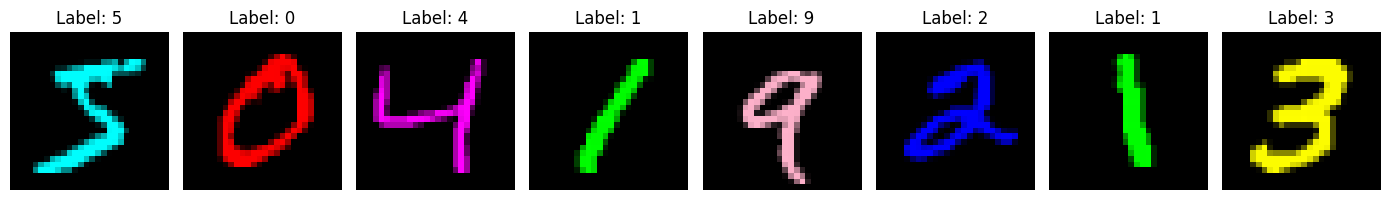

In [ ]:
# Visualize a Few Samples
def show_samples(dataset, num_samples=8):
    plt.figure(figsize=(14, 3))
    for i in range(num_samples):
        img, label = dataset[i]
        img_np = img.permute(1, 2, 0).cpu().numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_np)
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, num_samples=8)

In [ ]:
# RGB CNN Model
class CustomCMNISTCNN(nn.Module):
    def __init__(self):
        super(CustomCMNISTCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),   # changed 1 -> 3
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 24, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CustomCMNISTCNN().to(device)
print(model)

CustomCMNISTCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1176, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [ ]:
# Count Parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total trainable parameters:", count_parameters(model))

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

Total trainable parameters: 42866
features.0.weight 216
features.0.bias 8
features.3.weight 1152
features.3.bias 16
features.6.weight 3456
features.6.bias 24
classifier.1.weight 37632
classifier.1.bias 32
classifier.3.weight 320
classifier.3.bias 10


In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Train / Evaluate Functions
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, criterion, optimizer, epochs=10):
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    return train_losses, train_accuracies

In [ ]:
# Train on train_biased.pt
epochs = 10

train_losses, train_accuracies = train_model(
    model, train_loader, criterion, optimizer, epochs=epochs
)

Epoch [1/10] | Train Loss: 0.4010, Train Acc: 89.94%
Epoch [2/10] | Train Loss: 0.1060, Train Acc: 97.10%
Epoch [3/10] | Train Loss: 0.0644, Train Acc: 98.17%
Epoch [4/10] | Train Loss: 0.0473, Train Acc: 98.57%
Epoch [5/10] | Train Loss: 0.0385, Train Acc: 98.84%
Epoch [6/10] | Train Loss: 0.0308, Train Acc: 99.03%
Epoch [7/10] | Train Loss: 0.0264, Train Acc: 99.19%
Epoch [8/10] | Train Loss: 0.0216, Train Acc: 99.31%
Epoch [9/10] | Train Loss: 0.0200, Train Acc: 99.35%
Epoch [10/10] | Train Loss: 0.0178, Train Acc: 99.45%


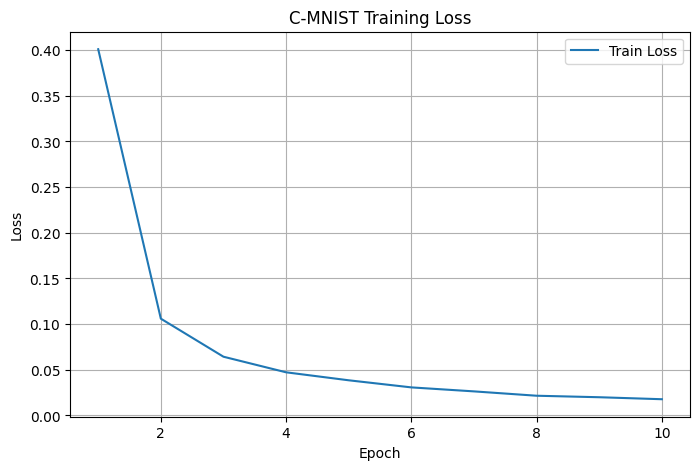

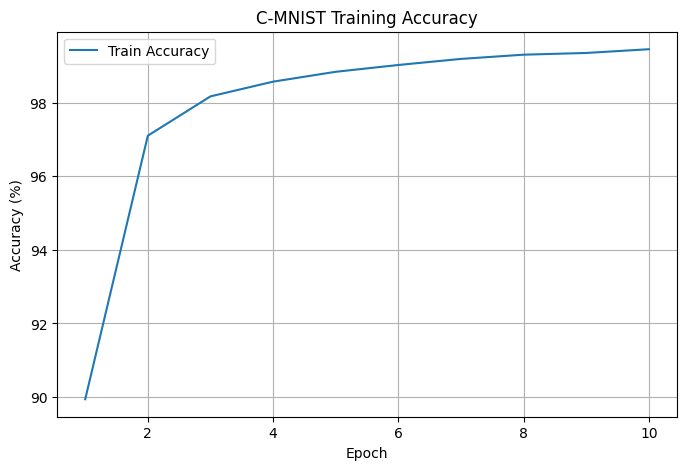

In [ ]:
# Plot Training Curves
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C-MNIST Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("C-MNIST Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate on Both Test Sets
test_biased_loss, test_biased_acc = evaluate(model, test_biased_loader, criterion)
test_unbiased_loss, test_unbiased_acc = evaluate(model, test_unbiased_loader, criterion)

print(f"Biased Test Loss: {test_biased_loss:.4f}")
print(f"Biased Test Accuracy: {test_biased_acc:.2f}%")

print(f"Unbiased Test Loss: {test_unbiased_loss:.4f}")
print(f"Unbiased Test Accuracy: {test_unbiased_acc:.2f}%")

Biased Test Loss: 0.0185
Biased Test Accuracy: 99.46%
Unbiased Test Loss: 0.2929
Unbiased Test Accuracy: 91.26%


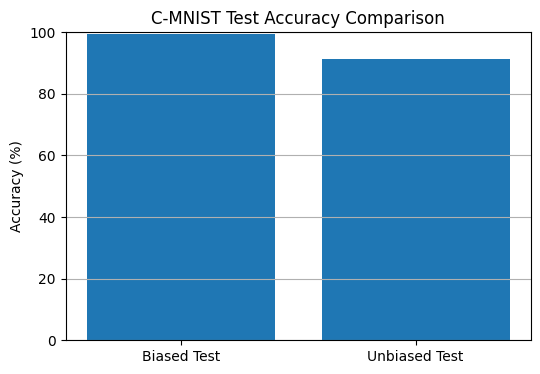

In [ ]:
# Compare the Two Results Visually
labels = ["Biased Test", "Unbiased Test"]
accuracies = [test_biased_acc, test_unbiased_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("C-MNIST Test Accuracy Comparison")
plt.ylim(0, 100)
plt.grid(axis="y")
plt.show()

In [ ]:
# Save Model
torch.save(model.state_dict(), "cmnist_model_partB.pth")
print("Model saved successfully.")

Model saved successfully.


**Task 2 (Transfer Learning and Interpretability) - Part A (Fine-tuning ResNet-18)**

In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Data Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load STL-10 Dataset
train_dataset = torchvision.datasets.STL10(
    root="./data",
    split="train",
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.STL10(
    root="./data",
    split="test",
    download=True,
    transform=test_transform
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 2.64G/2.64G [01:08<00:00, 38.6MB/s]


Train size: 5000
Test size: 8000


In [ ]:
# Load Pre-trained ResNet-18
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Freeze the Backbone
for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Replace the Classification Head
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [ ]:
# Verify the Trainable Parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

Total parameters: 11181642
Trainable parameters: 5130
fc.weight 5120
fc.bias 10


In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [ ]:
# Training and Evaluation Functions
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        test_loss, test_acc = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    return train_losses, test_losses, train_accuracies, test_accuracies

In [ ]:
# Train the Model
epochs = 10

train_losses, test_losses, train_accuracies, test_accuracies = train_model(
    model, train_loader, test_loader, criterion, optimizer, epochs=epochs
)

Epoch [1/10] | Train Loss: 0.9148, Train Acc: 77.92% | Test Loss: 0.3585, Test Acc: 92.49%
Epoch [2/10] | Train Loss: 0.3123, Train Acc: 92.72% | Test Loss: 0.2460, Test Acc: 93.79%
Epoch [3/10] | Train Loss: 0.2308, Train Acc: 94.48% | Test Loss: 0.2110, Test Acc: 94.09%
Epoch [4/10] | Train Loss: 0.1981, Train Acc: 94.68% | Test Loss: 0.1882, Test Acc: 94.33%
Epoch [5/10] | Train Loss: 0.1788, Train Acc: 94.86% | Test Loss: 0.1792, Test Acc: 94.53%
Epoch [6/10] | Train Loss: 0.1640, Train Acc: 95.34% | Test Loss: 0.1733, Test Acc: 94.50%
Epoch [7/10] | Train Loss: 0.1519, Train Acc: 95.60% | Test Loss: 0.1676, Test Acc: 94.66%
Epoch [8/10] | Train Loss: 0.1405, Train Acc: 96.24% | Test Loss: 0.1688, Test Acc: 94.45%
Epoch [9/10] | Train Loss: 0.1301, Train Acc: 96.02% | Test Loss: 0.1595, Test Acc: 94.65%
Epoch [10/10] | Train Loss: 0.1303, Train Acc: 95.94% | Test Loss: 0.1576, Test Acc: 94.72%


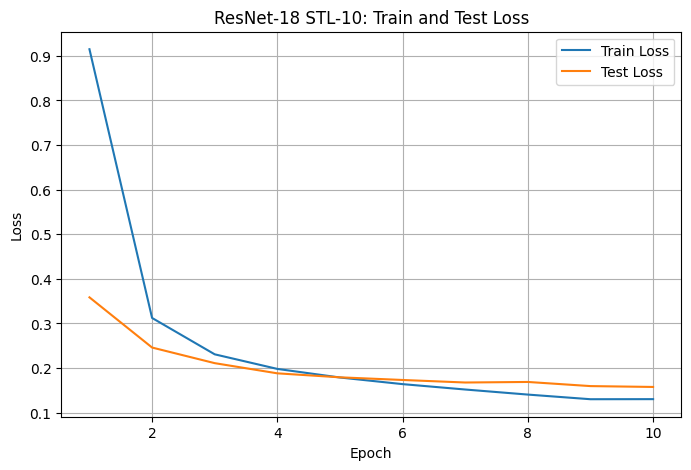

In [ ]:
# Plot Loss Curves
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 STL-10: Train and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

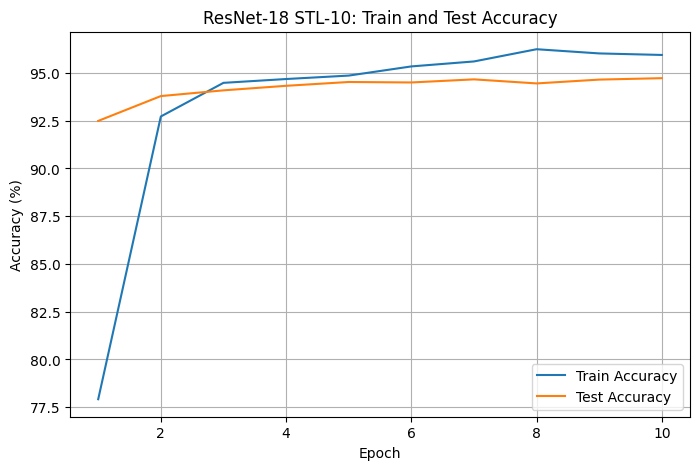

In [ ]:
# Plot Accuracy Curves
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, epochs+1), test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-18 STL-10: Train and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Final Evaluation
final_test_loss, final_test_acc = evaluate(model, test_loader, criterion)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

Final Test Loss: 0.1576
Final Test Accuracy: 94.72%


In [ ]:
# Save the Model
torch.save(model.state_dict(), "resnet18_stl10_finetuned_head.pth")
print("Model saved successfully.")

Model saved successfully.


**Task 2 (Transfer Learning and Interpretability) - Part B (Visualizing Decisions with GradCAM)**

In [ ]:
# Install GradCAM library
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 86.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Imports
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision.transforms.functional import to_pil_image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
# STL-10 class names
class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

In [ ]:
# Build a non-normalized test dataset for display
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

display_test_dataset = torchvision.datasets.STL10(
    root="./data",
    split="test",
    download=True,
    transform=display_transform
)

display_test_loader = DataLoader(display_test_dataset, batch_size=1, shuffle=False)

In [ ]:
# Normalizing Test Dataset
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = torchvision.datasets.STL10(
    root="./data",
    split="test",
    download=True,
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [ ]:
# Find 2 correct and 2 incorrect predictions
model.eval()

correct_samples = []
incorrect_samples = []

with torch.no_grad():
    for idx, ((input_img, label), (display_img, _)) in enumerate(zip(test_loader, display_test_loader)):
        input_img = input_img.to(device)
        label = label.to(device)

        outputs = model(input_img)
        pred = outputs.argmax(dim=1)

        sample = {
            "index": idx,
            "input_tensor": input_img.cpu(),
            "display_tensor": display_img.squeeze(0),
            "true_label": label.item(),
            "pred_label": pred.item()
        }

        if pred.item() == label.item() and len(correct_samples) < 2:
            correct_samples.append(sample)

        if pred.item() != label.item() and len(incorrect_samples) < 2:
            incorrect_samples.append(sample)

        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

print("Correct samples found:", len(correct_samples))
print("Incorrect samples found:", len(incorrect_samples))

for s in correct_samples:
    print("Correct -> index:", s["index"],
          "true:", class_names[s["true_label"]],
          "pred:", class_names[s["pred_label"]])

for s in incorrect_samples:
    print("Incorrect -> index:", s["index"],
          "true:", class_names[s["true_label"]],
          "pred:", class_names[s["pred_label"]])

Correct samples found: 2
Incorrect samples found: 2
Correct -> index: 0 true: horse pred: horse
Correct -> index: 1 true: monkey pred: monkey
Incorrect -> index: 9 true: deer pred: cat
Incorrect -> index: 17 true: truck pred: car


In [ ]:
# Create GradCAM object
target_layers = [model.layer4[-1].conv2]
cam = GradCAM(model=model, target_layers=target_layers)

In [ ]:
# Function to generate GradCAM overlay
def generate_gradcam(sample, use_predicted_class=True):
    model.eval()

    # input for model
    input_tensor = sample["input_tensor"].clone().to(device)
    input_tensor.requires_grad_(True)

    # image for display
    rgb_img = sample["display_tensor"].permute(1, 2, 0).cpu().numpy().astype(np.float32)

    if use_predicted_class:
        target_class = sample["pred_label"]
    else:
        target_class = sample["true_label"]

    targets = [ClassifierOutputTarget(target_class)]

    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    return rgb_img, grayscale_cam, visualization

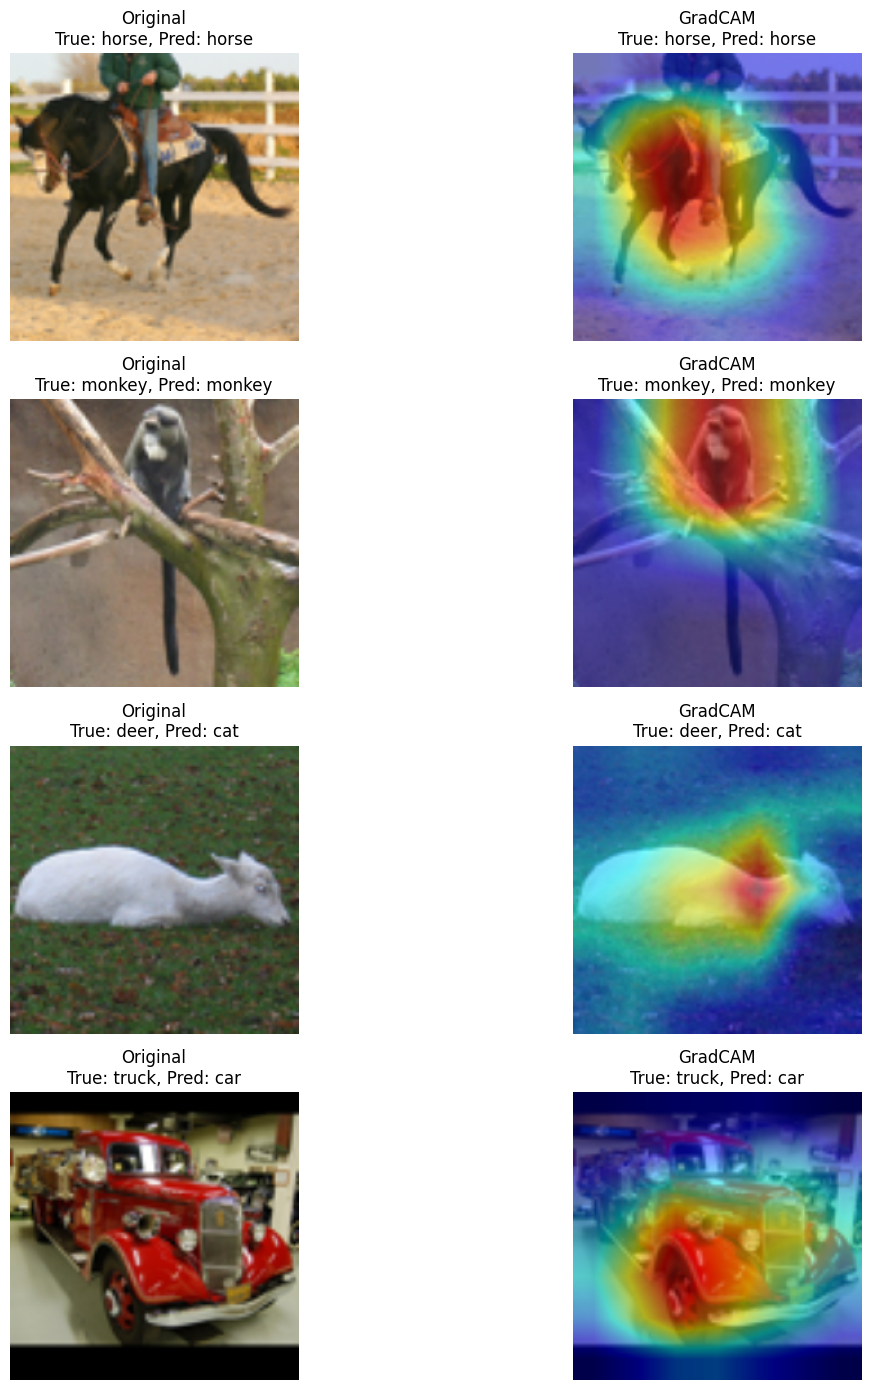

In [ ]:
# Visualize the 2 correct and 2 incorrect samples
all_samples = correct_samples + incorrect_samples

plt.figure(figsize=(14, 14))

for i, sample in enumerate(all_samples):
    rgb_img, grayscale_cam, visualization = generate_gradcam(sample, use_predicted_class=True)

    true_name = class_names[sample["true_label"]]
    pred_name = class_names[sample["pred_label"]]

    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(rgb_img)
    plt.title(f"Original\nTrue: {true_name}, Pred: {pred_name}")
    plt.axis("off")

    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(visualization)
    plt.title(f"GradCAM\nTrue: {true_name}, Pred: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

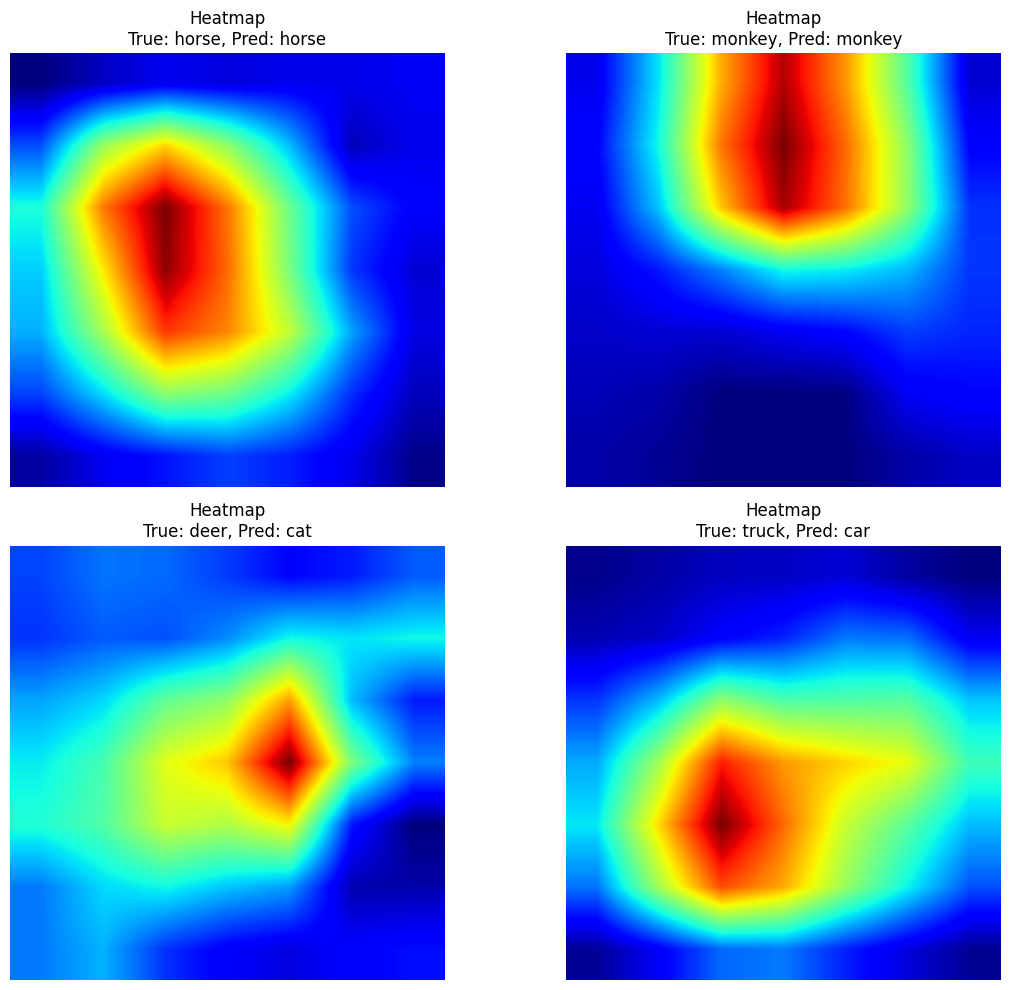

In [ ]:
# Show heatmap only
plt.figure(figsize=(12, 10))

for i, sample in enumerate(all_samples):
    _, grayscale_cam, _ = generate_gradcam(sample, use_predicted_class=True)

    true_name = class_names[sample["true_label"]]
    pred_name = class_names[sample["pred_label"]]

    plt.subplot(2, 2, i + 1)
    plt.imshow(grayscale_cam, cmap="jet")
    plt.title(f"Heatmap\nTrue: {true_name}, Pred: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

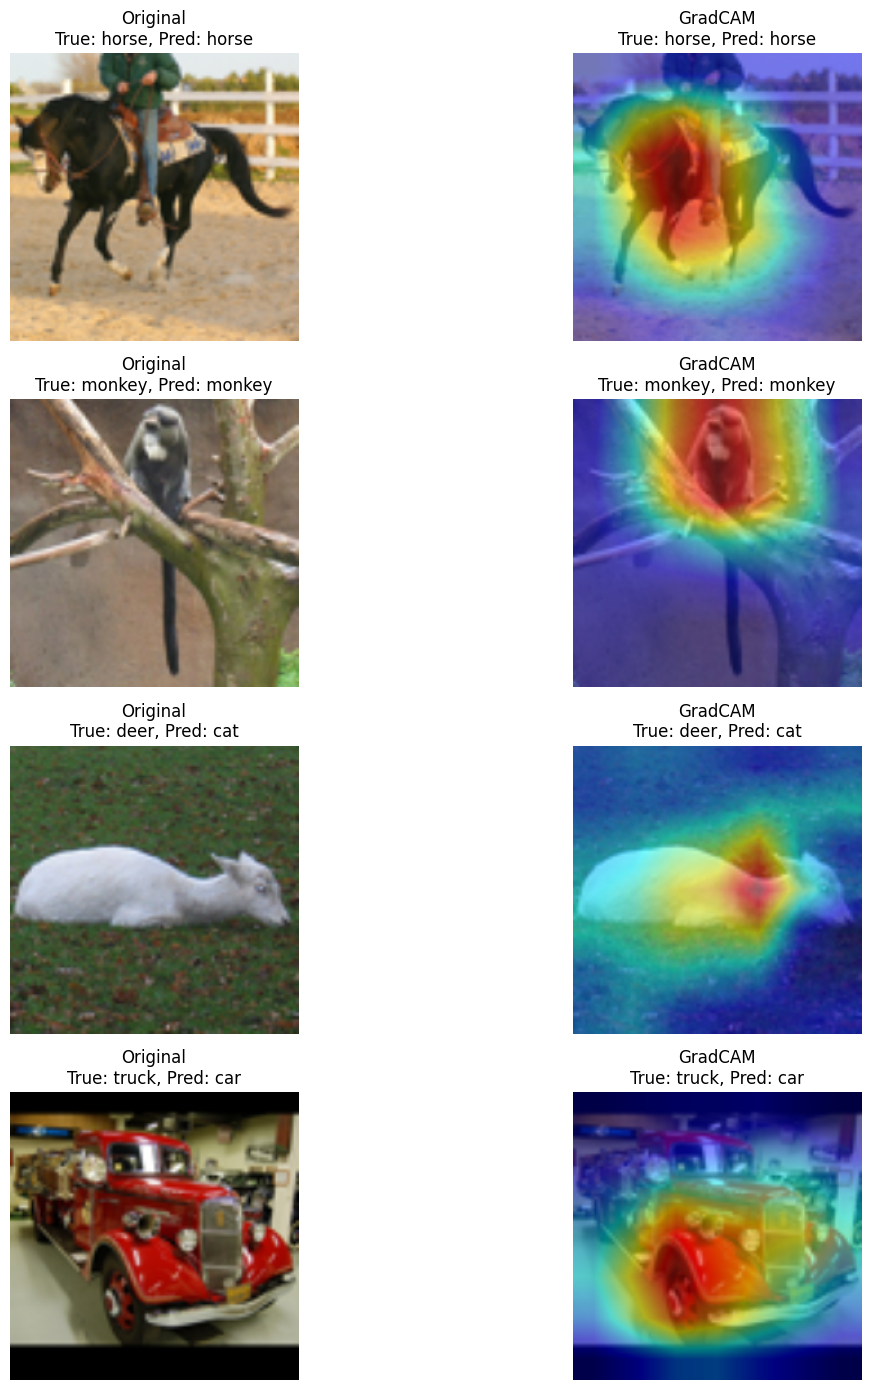

Saved as stl10_gradcam_results.png


In [ ]:
# Save the figure
fig = plt.figure(figsize=(14, 14))

for i, sample in enumerate(all_samples):
    rgb_img, grayscale_cam, visualization = generate_gradcam(sample, use_predicted_class=True)

    true_name = class_names[sample["true_label"]]
    pred_name = class_names[sample["pred_label"]]

    ax1 = fig.add_subplot(4, 2, 2*i + 1)
    ax1.imshow(rgb_img)
    ax1.set_title(f"Original\nTrue: {true_name}, Pred: {pred_name}")
    ax1.axis("off")

    ax2 = fig.add_subplot(4, 2, 2*i + 2)
    ax2.imshow(visualization)
    ax2.set_title(f"GradCAM\nTrue: {true_name}, Pred: {pred_name}")
    ax2.axis("off")

plt.tight_layout()
plt.savefig("stl10_gradcam_results.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as stl10_gradcam_results.png")